In [1]:
# %run validation.py --explanation_type=Self --seed=42

In [2]:

# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# train_dataset, test_dataset, estimators = load_data_and_estimators()

In [3]:
# from explanations import TopKMostInfluential,TopKLeastInfluential

In [4]:
# explanation = TopKMostInfluential(99,estimators[0],k=10)
# explanation.documents

In [5]:
# explanation.description

In [6]:
# train_dataset.select(explanation.documents)["messages"]

In [7]:
# train_dataset.select([explanation.document_idx])["messages"]

In [8]:
# TopKMostInfluential(1,estimators[1],k=10).documents

In [9]:
# trd6i7fogizöul

In [10]:
# %run merge_results.py

In [11]:
import os
from multiprocess import set_start_method
set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [12]:



import os
import torch

import argparse



In [13]:
# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# # train_dataset, test_dataset, estimators = load_data_and_estimators()


In [14]:
# from functools import partial
# from explanations import KRandom
# k_random_types = [partial(KRandom, seed=s) for s in range(9)]
# explanation_types = explanation_types + k_random_types

In [15]:
# import logging
# from concurrent.futures import ProcessPoolExecutor, as_completed
# import torch
# import multiprocessing
# from tqdm import tqdm
# import itertools
# import pandas as pd
# import traceback

# logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
# multiprocessing.set_start_method('spawn', force=True)
# torch.manual_seed(42)




# num_devices = torch.cuda.device_count()







In [16]:
import glob
import pandas as pd
import os

In [17]:
import pyarrow as pa
import pyarrow.parquet as pq

In [18]:
df_validation = pq.ParquetDataset("results/validation").read().to_pandas()


In [19]:
# df_scoring = merge_fragments_with_source_column_parallel( source_dir="cache/scoring/partial", target_dir="results/scoring")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [20]:
# df_scoring = load_or_merge_dataset( source_dir="cache/scoring/partial", target_dir="cache/scoring/full")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [21]:
# df_scoring = load_or_merge_dataset(
#     source_dir="cache/scoring/partial",
#     target_dir="cache/scoring/full"
# )


# df_scoring["linear_coder"] = df_scoring["source_file"].apply(
#     lambda path: os.path.basename(os.path.dirname(os.path.dirname(path)))
# )

In [22]:
import re

In [23]:
import re

def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))
    return None

df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
df_validation["explanation_type_no_k"] = df_validation.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)
import re

def replace_k_with_X(explanation_type):

    explanation_type = re.sub(r"Top-(\d+)", "Top-X", explanation_type)

    explanation_type = re.sub(r"(\d+)\s+random examples", "X random examples", explanation_type)
    return explanation_type



In [24]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]


In [25]:
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] >= r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] >= r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] >= r["kld(before||after)_random"]
r_summary = r.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                ]).agg(
                    mean_validation_score_log_p=("validation_score_log_p", "mean"),
                    count_validation_score_log_p=("validation_score_log_p", "count"),
                    mean_validation_score_jsd=("validation_score_jsd", "mean"),
                    count_validation_score_jsd=("validation_score_jsd", "count"),
                    mean_validation_score_kld=("validation_score_kld", "mean"),
                    count_validation_score_kld=("validation_score_kld", "count")
                    )
r_summary.sort_values(by="mean_validation_score_log_p", ascending=False)


mean_validation_score_log_p  \
estimator                                  explanation_type_selection                         model                                              train_dataset                                train_split test_dataset                                 test_split k                                 
DataInfEstimator: fast_implementation=True The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.979021   
LESSEstimator: normalize=True              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.978000   
BM25Estimator: k1=1.5, b=0.75              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.944444   
                                           Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.611111   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.588235   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.576923   
LESSEstimator: normalize=True              Top-25 most helpful (most negative scores)         OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25                     0.543000   
                                           Top-25 most harmful (most positive scores)         OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25                     0.516600   
                                           Top-25 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25                     0.516200   
                                           Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.512400   
                                           Top-1 most helpful (most negative scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.507800   
                                           Top-5 most helpful (most negative scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       5                      0.507000   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-s

In [26]:
# %run merge_results.py --source_dir="cache/scoring/partial" --target_dir="results/scoring"

In [27]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

df_scoring = pq.ParquetDataset("results/scoring").read().to_pandas()
df_scoring["k"] = df_scoring["explanation_type"].apply(extract_k)
df_scoring["explanation_type_no_k"] = df_scoring.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)


In [28]:
len(df_scoring)

518721

In [29]:
len(df_validation)

64778

In [30]:
rr = pd.merge(
    r,
    df_scoring,
    left_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type_selection", 
        "k",
        "document_idx"
    ],
    right_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type", 
        "k",
        "document_idx"
    ],
    suffixes=("_validation", "_scoring"),
    how="left"
)
rr["validation_score_log_p"] = rr["delta_log_p_selection"] >= rr["delta_log_p_random"]
rr["validation_score_jsd"] = rr["jsd_selection"] >= rr["jsd_random"]
rr["validation_score_kld"] = rr["kld(before||after)_selection"] >= rr["kld(before||after)_random"]
rr_summary = rr.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "linear_coder",
                    "explanation_type_no_k_selection",
                    # "explanation_type_random"
                ]).agg(
                    mean_pred_gain=("pred_gain", "mean"),
                    mean_mse=("mse", "mean"),
                    mean_validation_score_log_p=("validation_score_log_p", "mean"),
                    count_validation_score_log_p=("validation_score_log_p", "count"),
                    mean_validation_score_jsd=("validation_score_jsd", "mean"),
                    count_validation_score_jsd=("validation_score_jsd", "count"),
                    mean_validation_score_kld=("validation_score_kld", "mean"),
                    count_validation_score_kld=("validation_score_kld", "count")
                    )
rr_summary.sort_values(by="mean_mse", ascending=True)


mean_pred_gain  \
estimator                                  explanation_type_selection                         model                                              train_dataset                                train_split test_dataset                                 test_split k linear_coder                      explanation_type_no_k_selection                                      
BM25Estimator: k1=1.5, b=0.75              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1 MSECoderProjUSimp                 The test instance (as a sanity check)                  1079.999022   
                                                                                                                                                                                                                                                                    MSECoderProjUSimpSparse           The test instance (as a sanity check)                  1079.999022   
                                                                                                                                                                                                                                                                    MSECoderProjUSimpSparseSoftThresh The test instance (as a sanity check)                  1079.999022   
                                                                                                                                                                                                                                                                    MSECoder                          The test instance (as a sanity check)                  1079.999022   
                                                                                                                                                                                                                                                                    MSECoderNNLSL2                    The test instance (as a sanity check)                   871.876987   
...                                                                                                                                                                                                                                                                                                                                                                  ...   
DataInfEstimator: fast_implementation=True Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1 MSECoderProjUSimpSparse           Top-X most influential (scores with largest abs...        0.000307   
                                                                                                                                                                                                                                                                    MSECoderProjUSimpSparseSoftThresh Top-X most influential (scores with largest abs...        0.000307   
LESSEstimator: normalize=True              Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1 MSECoderProjUSimpSparseSoftThresh Top-X most influential (scores with largest abs...        0.000342   
                                                                                                                                                                                                                                                                    MSECoderProjUSimpSparse           Top-X most influential (scores with largest abs.

## global

In [31]:
rr.columns

Index(['explanation_type_selection', 'model', 'estimator', 'document_idx',
       'train_dataset', 'train_split', 'test_dataset', 'test_split',
       'indices_trained_on_selection', 'indices_target_document_selection',
       'delta_log_p_selection', 'log_p_before_selection',
       'log_p_after_selection', 'jsd_selection',
       'kld(before||after)_selection', 'k', 'explanation_type_no_k_selection',
       'explanation_type_random', 'indices_trained_on_random',
       'indices_target_document_random', 'delta_log_p_random',
       'log_p_before_random', 'log_p_after_random', 'jsd_random',
       'kld(before||after)_random', 'explanation_type_no_k_random',
       'validation_score_log_p', 'validation_score_jsd',
       'validation_score_kld', 'explanation_type', 'linear_coder', 'pred_gain',
       'mse', 'l1', 'l2', 't', 'explanation_type_no_k'],
      dtype='object')

In [32]:
rr["linear_coder"].unique()

array(['KLTCoder', 'MSECoder', 'MSECoderNNLSL2', 'MSECoderProjUSimp',
       'MSECoderProjUSimpSparse', 'MSECoderProjUSimpSparseSoftThresh',
       nan], dtype=object)

In [43]:
rr["log_p_ratio"] = (rr["log_p_after_selection"] -  rr["log_p_before_selection"]) / (rr["log_p_after_random"] -  rr["log_p_before_random"]) 
rr["log_p_ratio_2"] = (rr["log_p_after_selection"] ) / (rr["log_p_after_random"]) 
rr["log_p_delta"] = (rr["log_p_after_selection"] ) - (rr["log_p_after_random"]) 
rr["kld_ratio"] = (rr["jsd_selection"]) /  (rr["jsd_random"])
rr["jsd_ratio"] = (rr["kld(before||after)_selection"]) /  (rr["kld(before||after)_random"])

In [75]:
group_cols = [
    "linear_coder",
    "model",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    "estimator",
    "explanation_type"#_no_k_selection"
]

In [76]:
rr.columns

Index(['explanation_type_selection', 'model', 'estimator', 'document_idx',
       'train_dataset', 'train_split', 'test_dataset', 'test_split',
       'indices_trained_on_selection', 'indices_target_document_selection',
       'delta_log_p_selection', 'log_p_before_selection',
       'log_p_after_selection', 'jsd_selection',
       'kld(before||after)_selection', 'k', 'explanation_type_no_k_selection',
       'explanation_type_random', 'indices_trained_on_random',
       'indices_target_document_random', 'delta_log_p_random',
       'log_p_before_random', 'log_p_after_random', 'jsd_random',
       'kld(before||after)_random', 'explanation_type_no_k_random',
       'validation_score_log_p', 'validation_score_jsd',
       'validation_score_kld', 'explanation_type', 'linear_coder', 'pred_gain',
       'mse', 'l1', 'l2', 't', 'explanation_type_no_k', 'log_p_ratio',
       'log_p_ratio_2', 'kld_ratio', 'jsd_ratio', 'log_p_delta'],
      dtype='object')

In [96]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2)
    return ccc

pairs = [
    ('log_p_ratio', 'pred_gain'),
    ('log_p_ratio', 'mse'),
    
    ('log_p_delta', 'pred_gain'),  
    ('log_p_delta', 'mse'),         
    
    ('log_p_ratio_2', 'pred_gain'),
    ('log_p_ratio_2', 'mse'),
    
    
    ('jsd_ratio', 'pred_gain'),
    ('jsd_ratio', 'mse'),
    
    
    ('kld_ratio', 'pred_gain'),
    ('kld_ratio', 'mse'),
    
    ('validation_score_log_p', 'pred_gain'),
    ('validation_score_log_p', 'mse'),
    
    ('validation_score_jsd', 'pred_gain'),
    ('validation_score_jsd', 'mse'),
    
    ('validation_score_kld', 'pred_gain'),  
    ('validation_score_kld', 'mse')         
]

results = []


for group_name, group_df in rr[  (rr["linear_coder"] == "MSECoderProjUSimp") &
    (~rr["explanation_type"].str.contains("most neg", na=False))].groupby(group_cols):
    for x_col, y_col in pairs:
        valid = group_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(valid) < 2:  #
            continue

        x = valid[x_col].values
        y = valid[y_col].values

        # display(x)
        # display(y)
        # raise NotImplementedError
        try:
            pearson_corr, _ = pearsonr(x, y)
            spearman_corr, _ = spearmanr(x, y)
            ccc_val = concordance_correlation_coefficient(x, y)
            r2_val = r2_score(x, y)
        except Exception as e:
            pearson_corr = spearman_corr = ccc_val = r2_val = np.nan

        results.append({
            **{col: val for col, val in zip(group_cols, group_name if isinstance(group_name, tuple) else (group_name,))},
            'X': x_col,
            'Y': y_col,
            'Pearson': pearson_corr,
            'Spearman': spearman_corr,
            'CCC': ccc_val,
            'R2': r2_val
        })

report_df = pd.DataFrame(results)



/tmp/ipykernel_824503/2329530654.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, _ = pearsonr(x, y)
/tmp/ipykernel_824503/2329530654.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(x, y)
/tmp/ipykernel_824503/2329530654.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, _ = pearsonr(x, y)
/tmp/ipykernel_824503/2329530654.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(x, y)
/tmp/ipykernel_824503/2329530654.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, _ = pearsonr(x, y)
/tmp/ipykernel_824503/2329530654.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, 

/tmp/ipykernel_824503/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


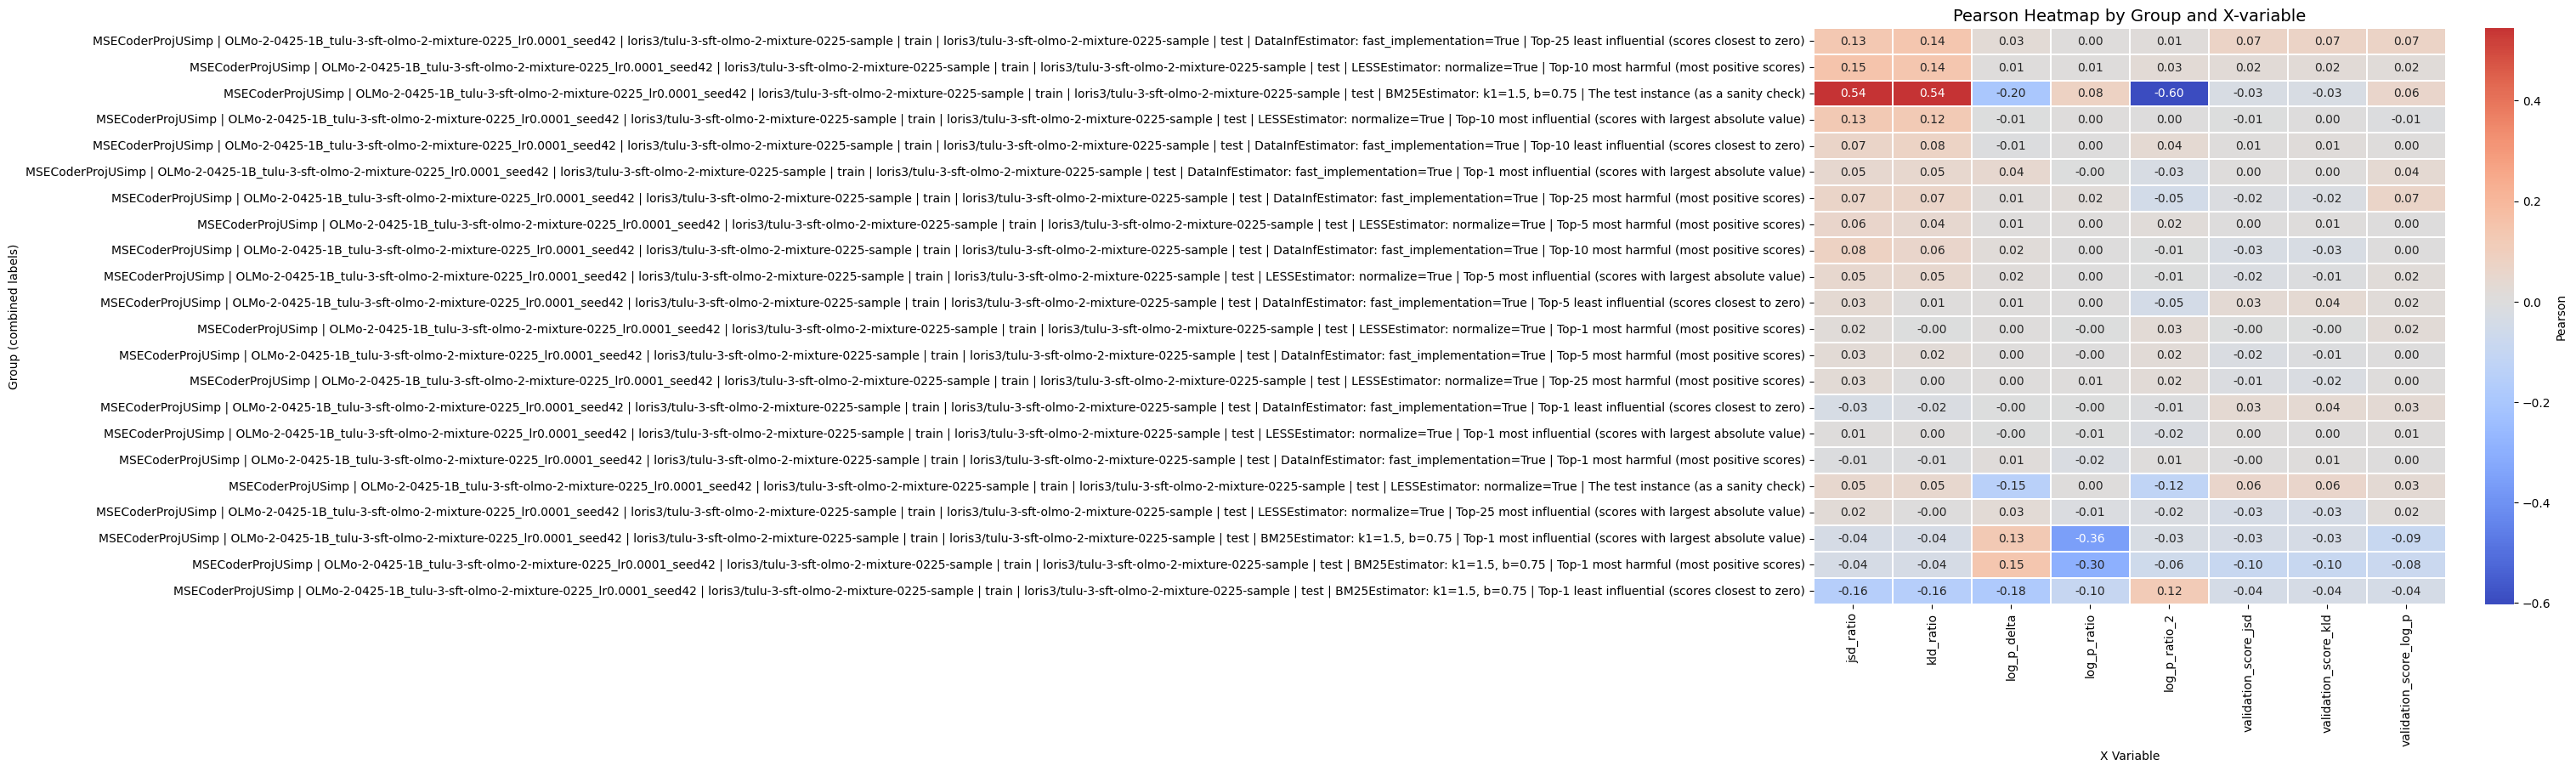

/tmp/ipykernel_824503/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


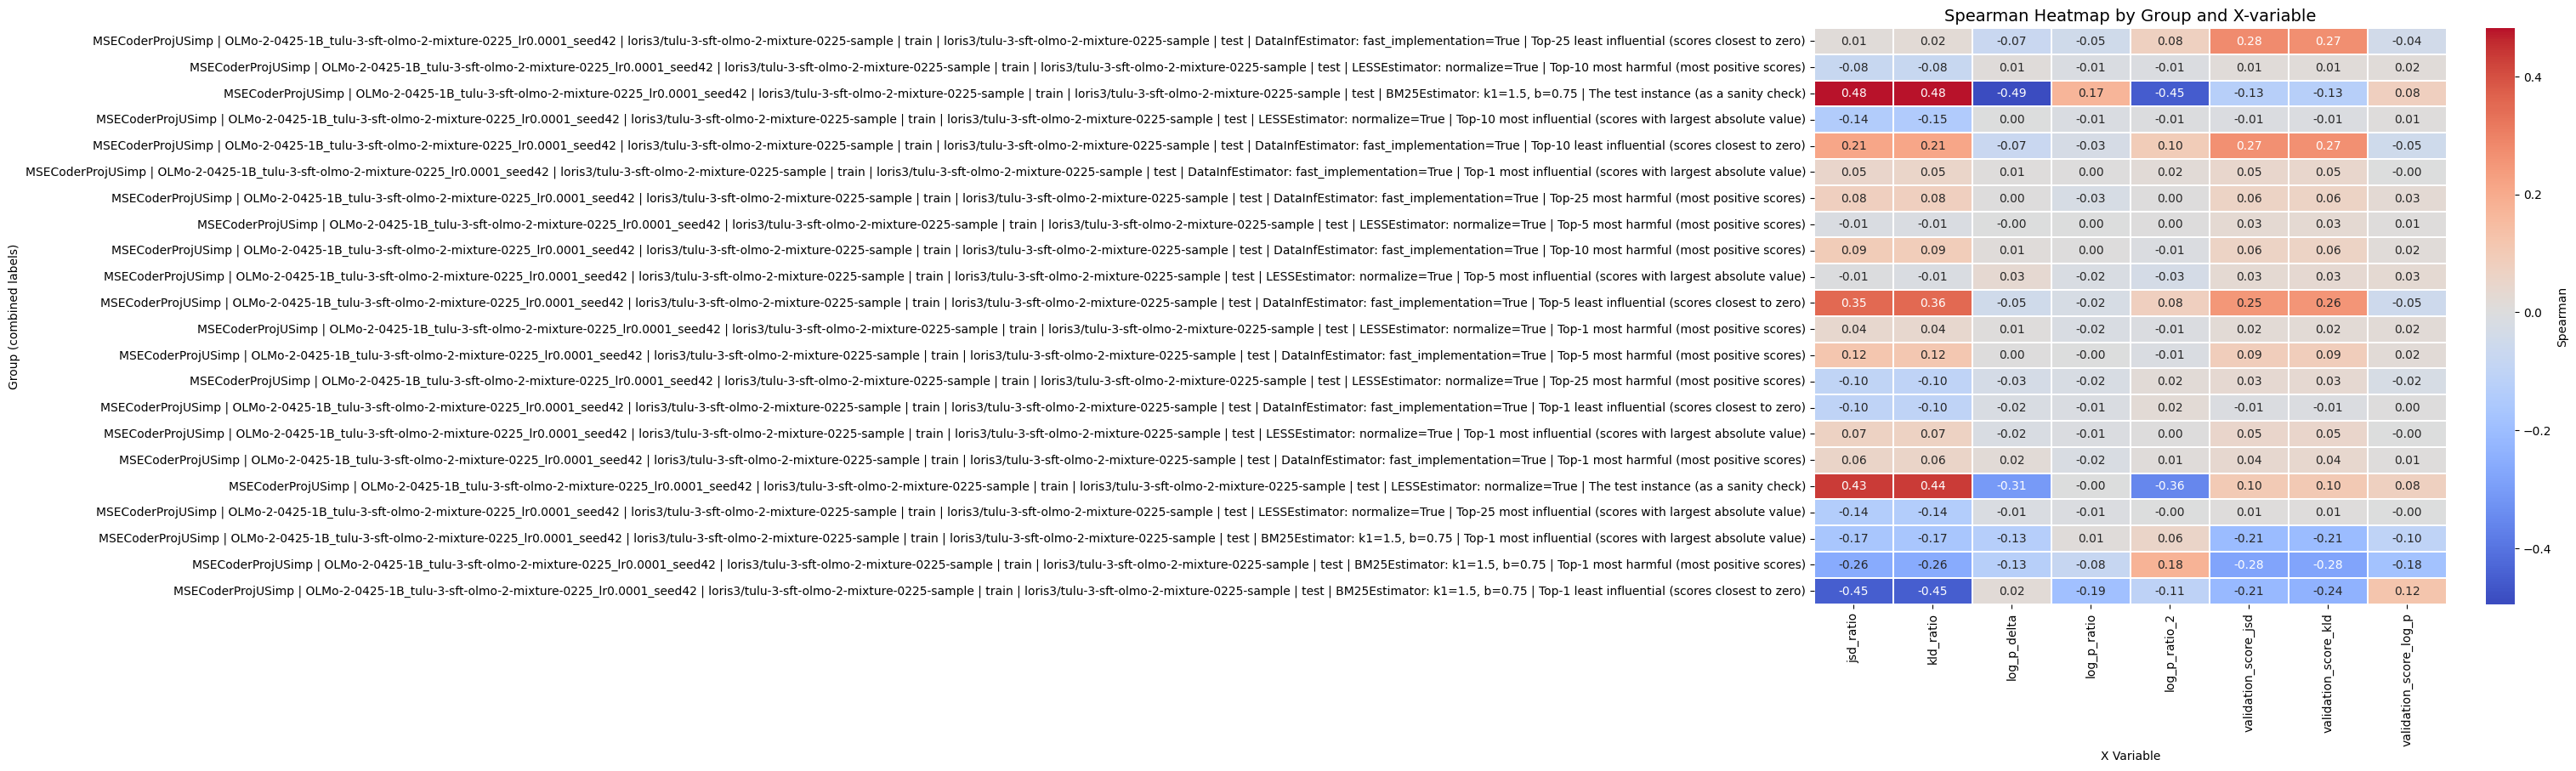

/tmp/ipykernel_824503/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


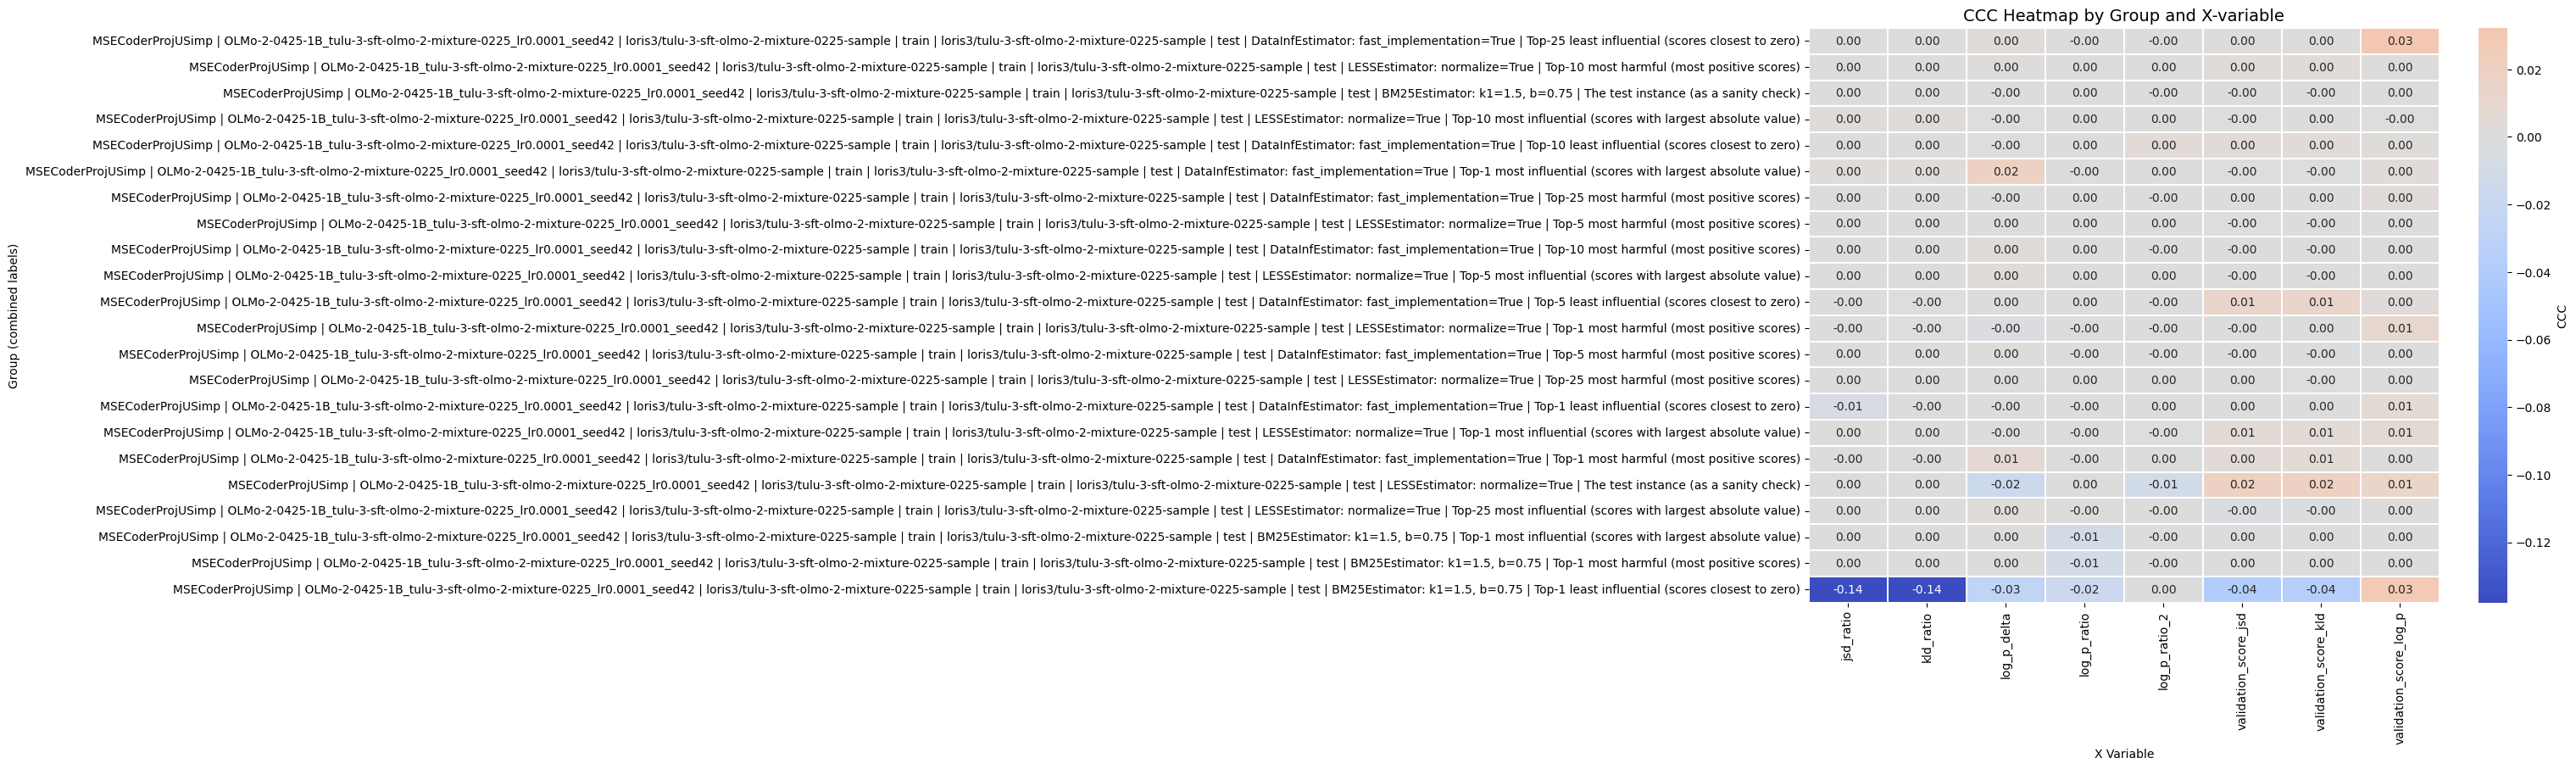

/tmp/ipykernel_824503/1495757571.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


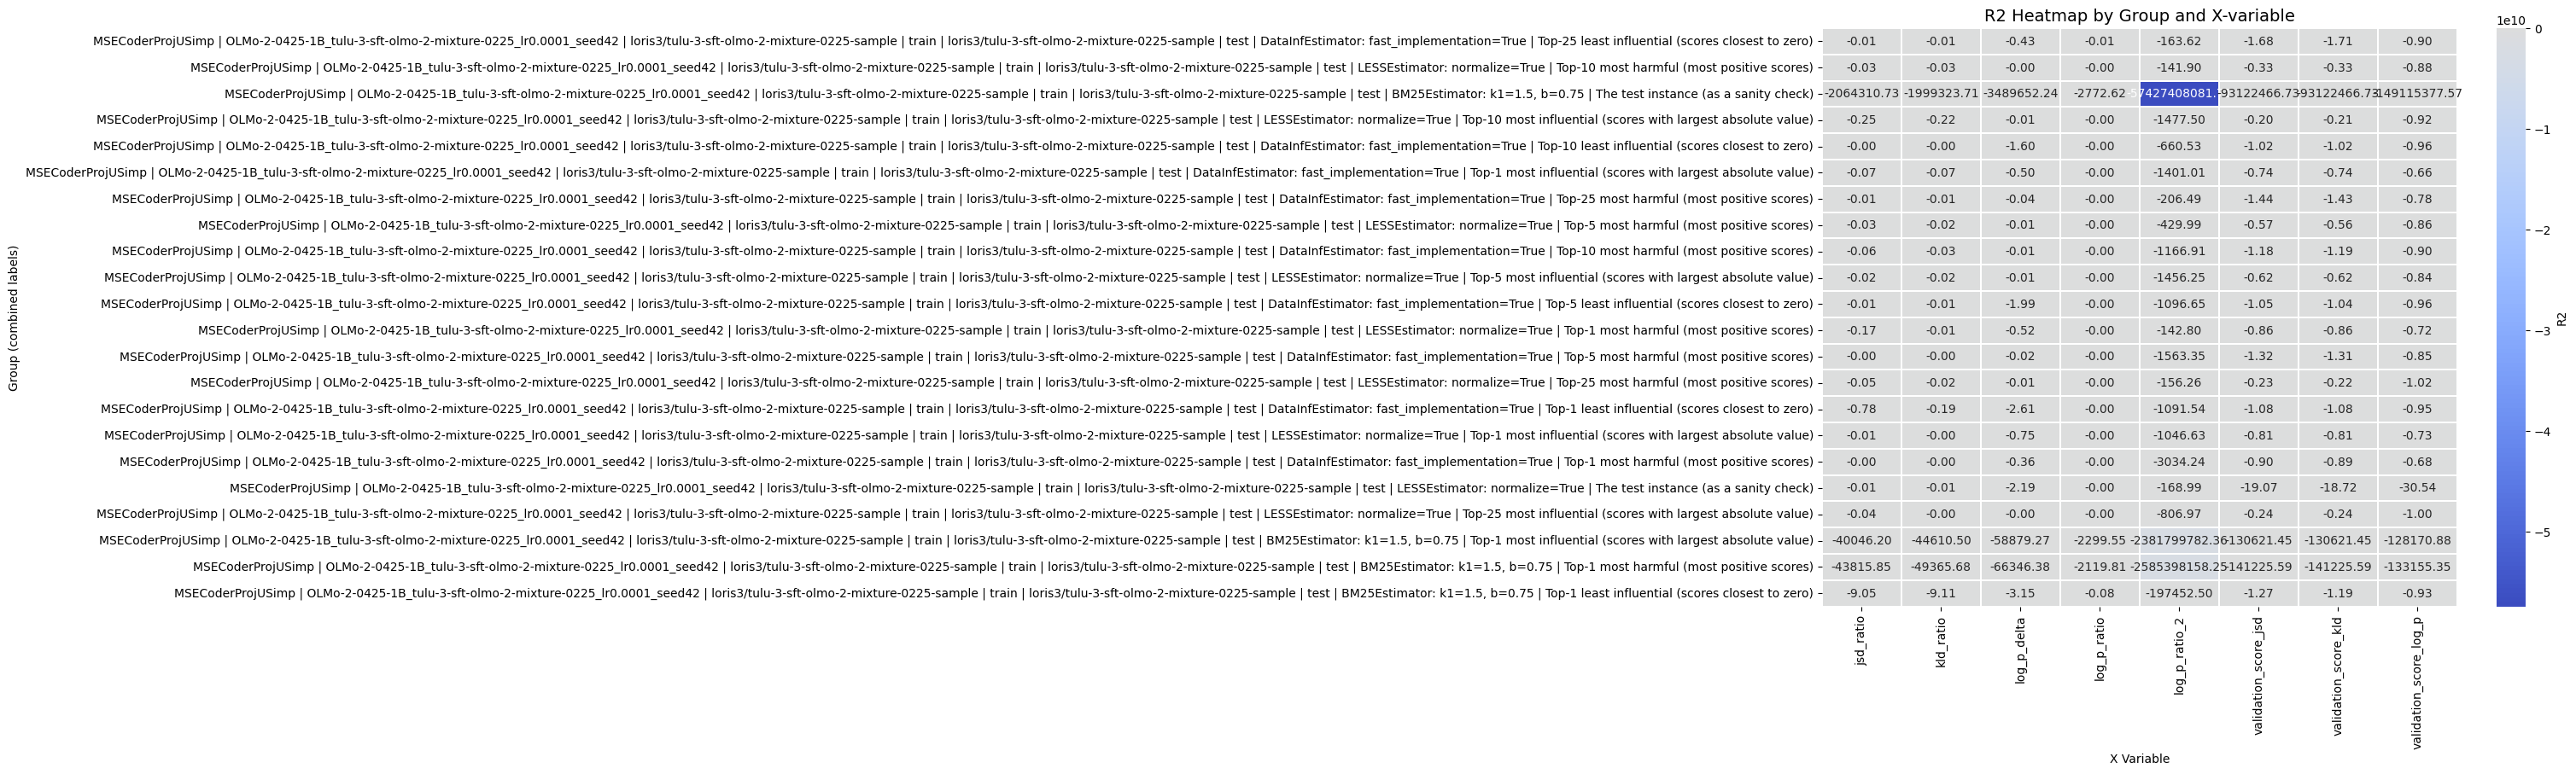

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
# -----------------------------
# Combine group columns for labeling
# -----------------------------
report_df["group_label"] = report_df[group_cols].astype(str).agg(" | ".join, axis=1)

# -----------------------------
# Plot heatmaps for each metric
# -----------------------------
metrics = ["Pearson", "Spearman", "CCC", "R2"]


base_metric = "Pearson"
base_pivot = report_df.pivot_table(
    index="group_label",
    columns="X",
    values=base_metric
)
base_order = (
    base_pivot.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

for metric in metrics:
    pivot_df = report_df.pivot_table(
        index="group_label",
        columns="X",
        values=metric
    )
    pivot_df = pivot_df.reindex(base_order)

    # Sort rows by average correlation
    # pivot_df["mean_corr"] = pivot_df.mean(axis=1)
    # pivot_df = pivot_df.sort_values("mean_corr", ascending=False).drop(columns="mean_corr")

    plt.figure(figsize=(12, max(6, 0.4 * len(pivot_df))))
    sns.heatmap(
        pivot_df, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, linewidths=0.3,
        cbar_kws={"label": metric}
    )
    plt.title(f"{metric} Heatmap by Group and X-variable", fontsize=14)
    plt.xlabel("X Variable")
    plt.ylabel("Group (combined labels)")
    plt.tight_layout()
    plt.show()



In [49]:
 mse_df.columns

Index(['model', 'train_dataset', 'train_split', 'test_dataset', 'test_split',
       'estimator', 'explanation_type', 'X', 'Y', 'Pearson', 'Spearman', 'CCC',
       'R2', 'group_label'],
      dtype='object')

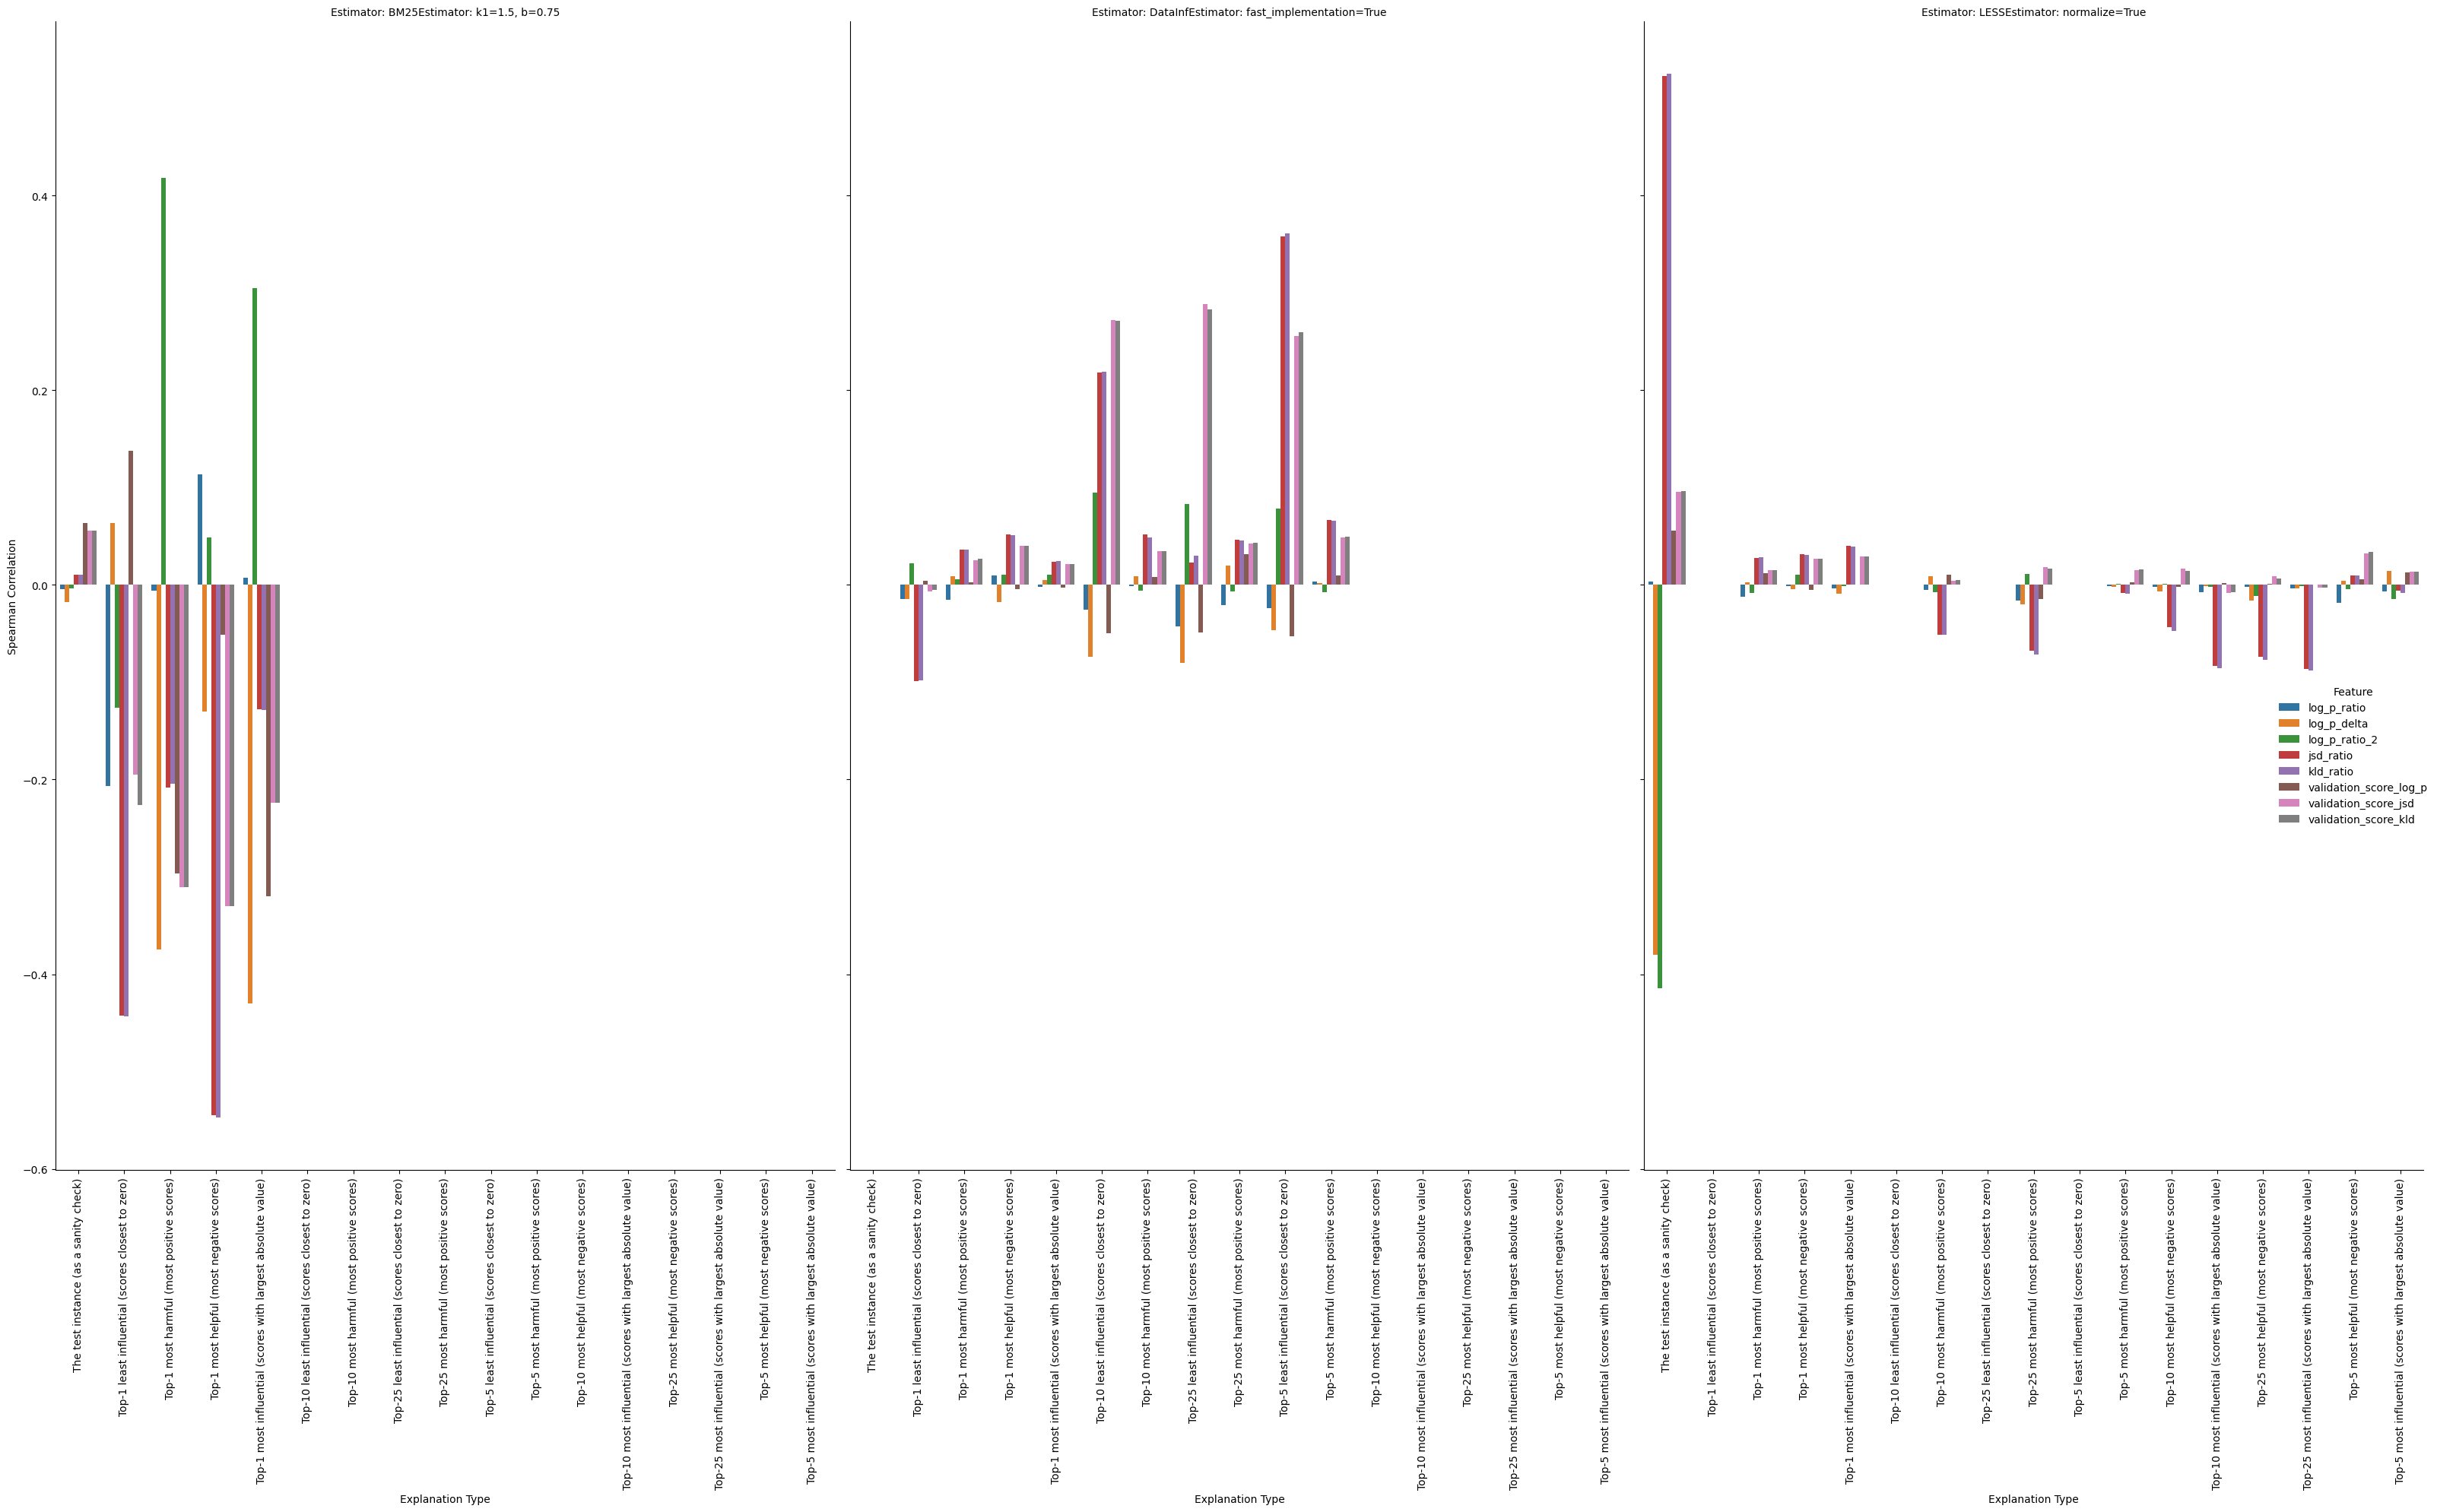

array([9.29047656e-06, 9.29041653e-06, 9.28805548e-06, ...,
       4.00680713e-02, 1.73073504e-02, 4.02191430e-02])

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for MSE correlations only
mse_df = report_df[report_df['Y'] == 'mse']

x_col = 'explanation_type'

# Create a faceted bar plot by estimator
g = sns.catplot(
    data=mse_df,
    x=x_col,
    y='Spearman',
    hue='X',            # group bars by feature
    col='estimator',    # facet by estimator
    kind='bar',
    palette='tab10',
    height=20,
    aspect=0.5
)

g.set_xticklabels(rotation=90)
g.set_axis_labels("Explanation Type", "Spearman Correlation")
g.set_titles("Estimator: {col_name}")
g._legend.set_title("Feature")
plt.tight_layout()
plt.show()
y

In [37]:
rr

,explanation_type_selection,model,estimator,document_idx,train_dataset,train_split,test_dataset,test_split,indices_trained_on_selection,indices_target_document_selection,...,pred_gain,mse,l1,l2,t,explanation_type_no_k,log_p_ratio,log_p_ratio_2,kld_ratio,jsd_ratio
0,The test instance (as a sanity check),OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,"BM25Estimator: k1=1.5, b=0.75",0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,...,0.998932,9.352574e-06,3.535406e-09,1.249910e-17,[3.5354059679804095e-09],The test instance (as a sanity check),9.808794,0.982539,1.439660,1.437478
1,The test instance (as a sanity check),OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,"BM25Estimator: k1=1.5, b=0.75",0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,...,935.256226,5.241125e-19,1.000000e+00,1.000000e+00,[1.000000238418579],The test instance (as a sanity check),9.808794,0.982539,1.439660,1.437478
2,The test instance (as a sanity check),OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,"BM25Estimator: k1=1.5, b=0.75",0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,...,443.129578,1.110572e-08,9.655406e-01,9.322686e-01,[0.9655405879020691],The test instance (as a sanity check),9.808794,0.982539,1.439660,1.437478
3,The test instance (as a sanity check),OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,"BM25Estimator: k1=1.5, b=0.75",0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,...,935.256226,0.000000e+00,1.000000e+00,1.000000e+00,[1.0],The test instance (as a sanity check),9.808794,0.982539,1.439660,1.437478
4,The test instance (as a sanity check),OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,"BM25Estimator: k1=1.5, b=0.75",0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,...,935.256226,0.000000e+00,1.000000e+00,1.000000e+00,[1.0],The test instance (as a sanity check),9.808794,0.982539,1.439660,1.437478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599257,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,999,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[7953, 80284, 78658, 45164, 72394]",999,...,1.051935,6.313329e-06,2.809214e-03,2.343286e-06,"[-0.00040528018143959343, 0.000627855130005627...",Top-X most influential (scores with largest ab...,0.532833,0.967331,24.899591,9.716338
599258,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,999,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[7953, 80284, 78658, 45164, 72394]",999,...,1.026290,6.471336e-06,4.204758e-03,6.229669e-06,"[0.0, 0.0, 0.0018553240224719048, 0.0010574082...",Top-X most influential (scores with largest ab...,0.532833,0.967331,24.899591,9.716338
599259,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,999,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[7953, 80284, 78658, 45164, 72394]",999,...,0.000166,4.006807e-02,9.999999e-01,2.000015e-01,"[0.1991949826478958, 0.20022812485694885, 0.20...",Top-X most influential (scores with largest ab...,0.532833,0.967331,24.899591,9.716338
599260,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,999,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[7953, 80284, 78658, 45164, 72394]",999,...,0.000384,1.730735e-02,1.000000e+00,2.500007e-01,"[0.0, 0.25002688169

In [38]:
 cd5r76t8izohlk

NameError: name 'cd5r76t8izohlk' is not defined

In [ ]:
corr_summary

In [ ]:
rr

In [ ]:
zgfuipdenya,lö

In [ ]:
results_df.groupby(["linear_coder", "explanation_type","model","estimator"]).mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_rel

results = []

for (k, exp_type,linear_coder), group in results_df.groupby(['k', 'explanation_type', 'linear_coder']):
    # paired test: selection vs random
    t_stat, p_value = ttest_rel(group['validation_score'], group['pred_gain_random'], alternative='greater')
    results.append({'k': k,"linear_coder":linear_coder, 'explanation_type': exp_type, 't_stat': t_stat, 'p_value': p_value})

pd.DataFrame(results)



In [ ]:
from scipy.stats import wilcoxon
w_stat, p_value = wilcoxon(group['validation_score'], group['pred_gain_random'], alternative='greater')
w_stat

In [ ]:
p_value

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Drop NaNs
df = results_df.dropna(subset=["validation_score", "pred_gain_selection", "pred_gain_random"])

# Mixed-effects model
# 'random_run' is a grouping variable (random intercept)
# You can optionally include 'explanation_type' as another random effect
md = smf.mixedlm(
    "validation_score ~ pred_gain_selection + pred_gain_random",
    df,
    groups=df["random_run"]
)
mdf = md.fit()
print(mdf.summary())


In [ ]:
corr_selection = results_df['validation_score'].corr(results_df['pred_gain_selection'])
corr_random = results_df['validation_score'].corr(results_df['pred_gain_random'])

print(f"Correlation with pred_gain_selection: {corr_selection:.3f}")
print(f"Correlation with pred_gain_random: {corr_random:.3f}")


In [ ]:
import statsmodels.api as sm

# Validation score ~ pred_gain_selection
X1 = sm.add_constant(results_df['pred_gain_selection'])
model1 = sm.OLS(results_df['validation_score'], X1).fit()
print(model1.summary())

# Validation score ~ pred_gain_random
X2 = sm.add_constant(results_df['pred_gain_random'])
model2 = sm.OLS(results_df['validation_score'], X2).fit()
print(model2.summary())


In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = -pd.to_numeric(group["mse"], errors="coerce")  # negate MSE so lower is better
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(pd.DataFrame({"neg_mse": x_clean}))
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("neg_mse", None),       
        "p_value": model.pvalues.get("neg_mse", None),  
        "r_squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df


In [ ]:
import statsmodels.api as sm

results = []


for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = pd.to_numeric(group["pred_gain"], errors="coerce")
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(x_clean)
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("pred_gain", None),
        "p_value": model.pvalues.get("pred_gain", None),
        "r_squared": model.rsquared
    })


results_df = pd.DataFrame(results)
results_df
